# Ⅰ. 데이터 처리  
## feature rescale

In [ ]:
A=[[176.5,1.2],[169.2,0.8],[180.3,0.1],[162.7,0.5]]
print(A[0])

In [ ]:
print(A[:,0])  #List

In [ ]:
import numpy as np
nA = np.array(A)
print(nA[0])
print(nA[:,0])  #Numpy

In [ ]:
print(nA[:,:1])

In [ ]:
# 키가 165 이상이면 165로 수정하여 다시 nA를 출력해보자.
nA = np.where(nA>=165, 165, nA)                #빈칸 채우기
print(nA)

In [ ]:
# 지수형이 아닌 소숫점 형태로 출력해보자.
np.set_printoptions(suppress=True)
print(nA)

**표준화**

In [ ]:

import numpy as np

Health=np.array([[176.5,1.2],[169.2,0.8],[180.3,0.1],[162.7,0.5]])

Health_std=np.copy(Health) #배열의 복사본
for i in range(Health.      ):   #빈칸 채우기(1)
    avg=                         #빈칸 채우기(2)
    std=                         #빈칸 채우기(3)
    Health_std[:,i]=             #빈칸 채우기(4)
print(Health_std)


**정규화**

In [ ]:
import numpy as np

Health=np.array([[176.5,1.2],[169.2,0.8],[180.3,0.1],[162.7,0.5]])
Health_norm=np.copy(Health)
for i in range(          ): #빈칸 채우기(1)
    Health_norm[:,i]=                      #빈칸 채우기(2)
    Health_norm[:,i]=                      #빈칸 채우기(3)
print(Health_norm)


**sklearn Library**

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

#(1)표준화-사이킷런 라이브러리 활용
Health=np.array([[176.5,1.2],[169.2,0.8],[180.3,0.1],[162.7,0.5]])
Health_std2=                         #빈칸 채우기
print('표준화(사이킷런 라이브러리) : \n', Health_std2)
print()

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

#(2)정규화 - 사이킷런 라이브러리 활용
Health=np.array([[176.5,1.2],[169.2,0.8],[180.3,0.1],[162.7,0.5]])
Health_norm2=                         #빈칸 채우기
print(Health_norm2)

# 개인과제(문제해결)

**csv 데이터를 찾고 feature(열)의 scale을 조정해 보세요.**

### 추천 데이터셋: Wine Quality (와인 품질)
이 데이터셋은 특성들 간의 수치 범위가 제각각이라 **Feature Scaling(표준화/정규화)** 실습에 매우 적합합니다.

In [1]:
import pandas as pd
import numpy as np

# Wine Quality 데이터셋 다운로드 (Red Wine)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(url, sep=';')

# 파일로 저장
df.to_csv('wine_quality.csv', index=False)

# numpy로 로드 (과제 형식에 맞춤)
data = np.loadtxt('wine_quality.csv', delimiter=',', skiprows=1)

print("데이터 로드 완료: wine_quality.csv")
print("데이터 크기:", data.shape)
display(df.head())

데이터 로드 완료: wine_quality.csv
데이터 크기: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.covariance import EllipticEnvelope

# 1. 데이터 로드
df = pd.read_csv('wine_quality.csv')

# 2. 이상치 처리 (Scikit-learn의 EllipticEnvelope 활용)
# 이 클래스는 내부적으로 마할라노비스 거리를 사용하여 이상치를 탐지합니다.
ee = EllipticEnvelope(contamination=0.05, random_state=42)

# 수치형 특성들 추출
features = df.drop('quality', axis=1)

# 이상치 판별 (1: 정상, -1: 이상치)
mask = ee.fit_predict(features)
df = df[mask == 1]

print(f"EllipticEnvelope(Mahalanobis) 적용 후 데이터 크기: {df.shape}")

# 3. 정규화 (Normalization)
X = df.drop('quality', axis=1)
y = df['quality']

scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

# 4. 일반화 (데이터 분할)
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)

print("전처리 및 분할 완료:")
print(f"학습 데이터셋 크기: {X_train.shape}")
print(f"테스트 데이터셋 크기: {X_test.shape}")
display(df.head())

EllipticEnvelope(Mahalanobis) 적용 후 데이터 크기: (1519, 12)
전처리 및 분할 완료:
학습 데이터셋 크기: (1215, 11)
테스트 데이터셋 크기: (304, 11)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [8]:
# 전처리된 데이터를 새로운 CSV 파일로 저장
df.to_csv('wine_quality_refined.csv', index=False)

print("가공된 데이터 저장 완료: wine_quality_refined.csv")
print(f"최종 데이터 행 개수: {len(df)}")

가공된 데이터 저장 완료: wine_quality_refined.csv
최종 데이터 행 개수: 1519


### Ⅱ. 탐색적 데이터 분석 (EDA)
로드한 Wine Quality 데이터를 분석하여 데이터의 분포와 특성을 파악합니다.

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 기본 정보 및 결측치 확인
print("--- 데이터 기본 정보 ---")
print(df.info())

print("\n--- 결측치 합계 ---")
print(df.isnull().sum())

# 2. 기술 통계량 확인
print("\n--- 기술 통계량 ---")
display(df.describe())

--- 데이터 기본 정보 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

--- 결측치 합계 ---
fixed acidity           0
volatile acidity        0
citric acid             0
residual 

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


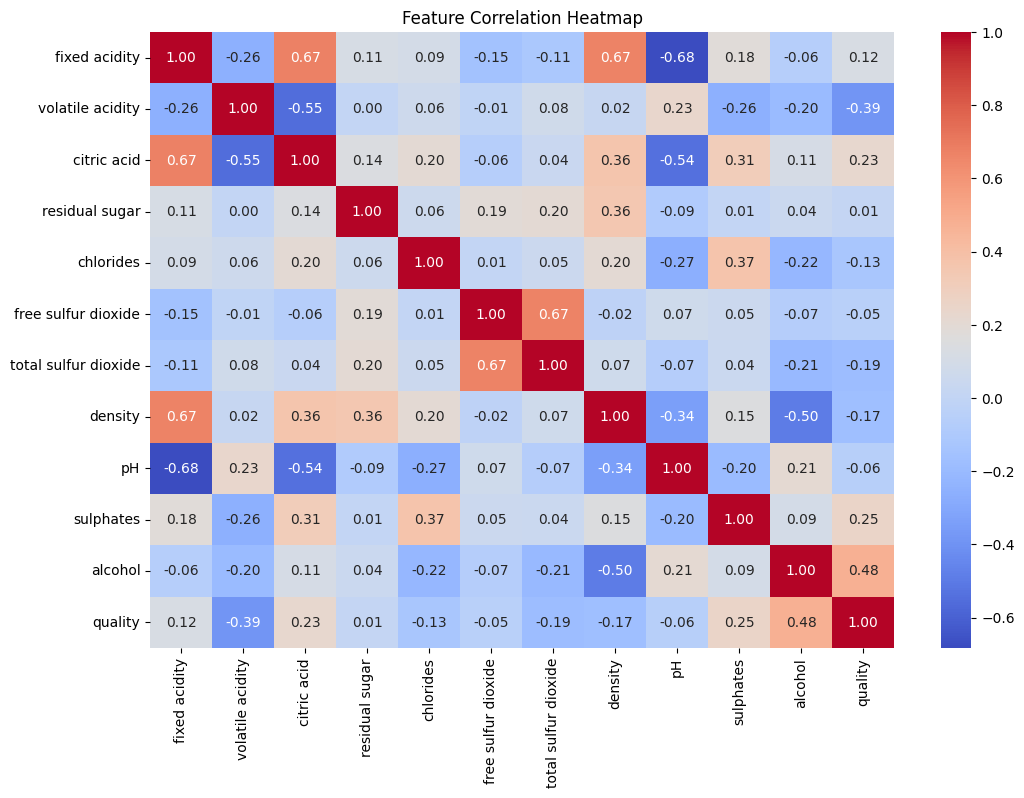

In [4]:
# 3. 상관관계 히트맵
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

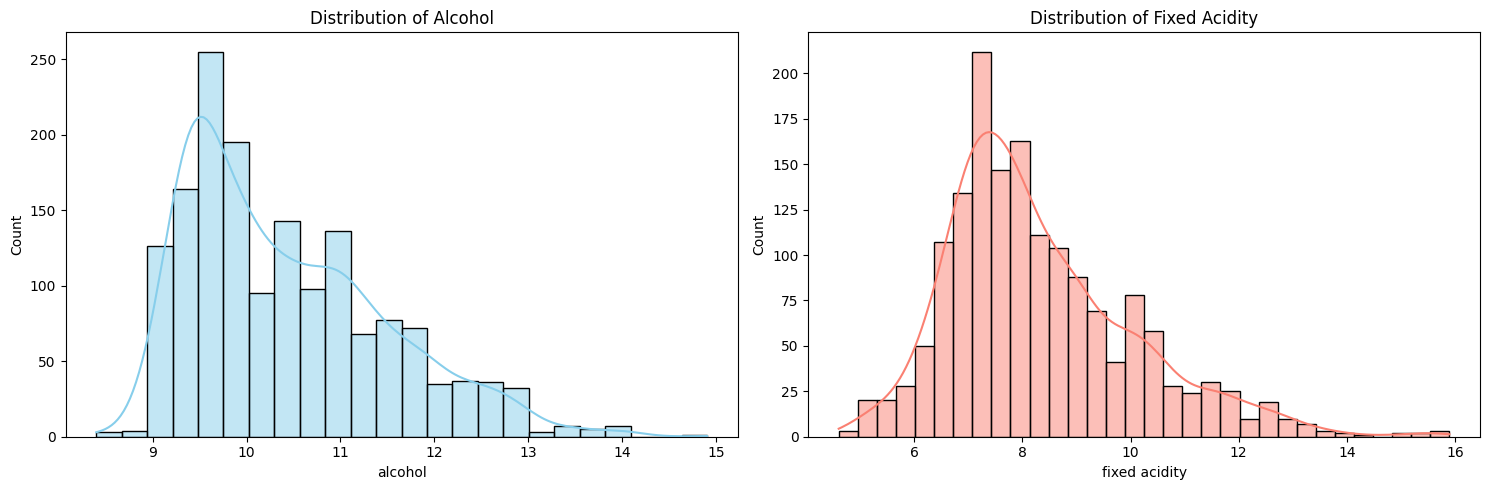

In [5]:
# 4. 주요 특성의 분포 확인 (예: alcohol, acidity)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['alcohol'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Alcohol')

sns.histplot(df['fixed acidity'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Fixed Acidity')

plt.tight_layout()
plt.show()

# 그 외 데이터 전처리

## 1. 결측치(Missing Value) 처리

실제 데이터에는 값이 비어 있는 경우가 많습니다. 이를 평균이나 중앙값으로 채우는 방법을 배웁니다.

**[문제]**
다음 데이터에서 나이(Age)의 결측치는 평균값으로, 점수(Score)의 결측치는 0으로 채우는 코드를 작성하세요.

**[코드]**

In [ ]:
import pandas as pd
import numpy as np

# 데이터 생성
data = {'Name': ['Kim', 'Lee', 'Park', 'Choi'],
        'Age': [25, np.nan, 30, 22],
        'Score': [85, 92, np.nan, 78]}
df = pd.DataFrame(data)

print("원본 데이터:\n", df)

# 1. Age의 결측치를 평균으로 채우기
df['Age'] = df['Age'].fillna(df['Age'].mean())

# 2. Score의 결측치를 0으로 채우기
df['Score'] = df['Score'].fillna(0)

print("\n결측치 처리 후:\n", df)

**[해설]**

* `fillna()` 함수는 데이터프레임 내의 NaN(Not a Number) 값을 지정한 값으로 대체합니다.
* 머신러닝 모델은 입력값에 결측치가 있으면 에러가 발생하므로, 반드시 통계값이나 특정값으로 보정해야 합니다.
---

## 2. 원-핫 인코딩 (One-Hot Encoding)

컴퓨터는 '사과', '배' 같은 문자열을 직접 계산할 수 없습니다. 이를 0과 1로 변환하는 기법입니다.


**[문제]**
과일 종류(['사과', '배', '포도']) 데이터를 원-핫 인코딩을 통해 수치형 데이터로 변환하세요.

**[코드]**

In [ ]:
import pandas as pd

# 범주형 데이터 생성
df = pd.DataFrame({'과일': ['사과', '배', '포도', '사과', '포도']})

# 원-핫 인코딩 적용
df_encoded = pd.get_dummies(df, columns=['과일'])

print("원-핫 인코딩 결과:\n", df_encoded)

**[해설]**

* `pd.get_dummies()`는 텍스트 데이터를 각 카테고리별 열(Column)로 나누고, 해당하면 1, 아니면 0을 부여합니다.
* 다중 분류 문제에서 레이블 간의 순서가 없을 때 주로 사용합니다.
---

## 3. 이상치(Outlier) 탐지와 제거

평균에서 너무 멀리 떨어진 데이터는 학습을 방해할 수 있습니다. 3표준편차($3\sigma$) 법칙을 활용해 제거해 봅니다.

**[문제]**
데이터 중 평균에서 $\pm 3\sigma$를 벗어나는 이상치를 찾아 제거하는 코드를 작성하세요.

**[코드]**

In [ ]:
import numpy as np

data = np.array([10, 12, 12, 13, 12, 11, 14, 13, 15, 10, 100]) # 100은 이상치
avg = np.mean(data)
std = np.std(data)

# 임계치 설정 (평균으로부터 3표준편차)
limit_high = avg + 3 * std
limit_low = avg - 3 * std

# 이상치 제거
filtered_data = data[(data > limit_low) & (data < limit_high)]

print(f"원본 데이터: {data}")
print(f"이상치 제거 후: {filtered_data}")

**[해설]**

* 정규분포에서 $99.7%$의 데이터는 $\pm 3\sigma$ 안에 들어옵니다. 이를 벗어나는 값은 측정 오류나 특이 사례로 간주하여 학습 데이터에서 제외하곤 합니다.

---


## 4. 데이터 셔플(Shuffle) 및 분할

데이터가 순서대로 정렬되어 있으면 모델이 특정 패턴에 편향될 수 있습니다. 이를 섞고 학습/테스트 용으로 나눕니다.

**[문제]**
`sklearn`을 사용하여 데이터를 8:2 비율로 섞어서 분할하세요.

**[코드]**

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# 0~99까지의 데이터 생성
X = np.arange(100).reshape((50, 2)) # 특성
y = np.arange(50) # 정답

# 데이터를 8:2 비율로 분할 (random_state는 결과 재현을 위함)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"학습 데이터 개수: {len(X_train)}")
print(f"테스트 데이터 개수: {len(X_test)}")

**[해설]**

* `train_test_split`은 데이터를 무작위로 섞은 뒤 지정한 비율(`test_size`)만큼 테스트용으로 떼어줍니다.
* 모델의 성능을 공정하게 평가하기 위해 반드시 학습에 쓰이지 않은 테스트 데이터가 필요합니다.

---


## 5. 특성 생성 (Feature Interaction)

두 개 이상의 특성을 곱하거나 더해 새로운 의미를 갖는 특성을 만듭니다.


**[문제]**
가로(Width)와 세로(Height) 데이터를 곱하여 '넓이(Area)'라는 새로운 특성을 데이터프레임에 추가하세요.

**[코드]**

In [ ]:
import pandas as pd

# 사각형 데이터
rects = pd.DataFrame({
    'Width': [10, 20, 15],
    'Height': [5, 4, 10]
})

# 두 특성을 결합하여 새로운 특성 생성
rects['Area'] = rects['Width'] * rects['Height']

print("특성 추가 결과:\n", rects)

**[해설]**

* 단순한 원본 데이터보다 여러 변수를 조합한 데이터가 모델의 예측력을 높이는 경우가 많습니다.
* 인공지능 프로그래밍 수업에서 학생들에게 '어떤 특성이 예측에 더 중요할까?'라는 주제로 토론하기 좋은 예시입니다.

---